<a href="https://colab.research.google.com/github/peterdomjan-maker/Biomed2026/blob/main/S1_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOMED-DATA 26 · Session 1
## Foundations and the data
**First contact with UCI Heart Disease: load it, explore it, and fit a first model**

> **STUDENT — fill in the blanks**
>
> Dataset: UCI Heart Disease (`ucimlrepo`, id=45). Runs in Colab: `Runtime → Run all`.
> Semmelweis University · Luca Szegletes (BME)
---

In [1]:
# Install packages (Colab). Skip if running locally with these already installed.
!pip -q install ucimlrepo scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 0. Load the data

In [3]:
# UCI Heart Disease (Cleveland), id=45
from ucimlrepo import fetch_ucirepo
heart = fetch_ucirepo(id=45)
X = heart.data.features.copy()
y_raw = heart.data.targets.copy()   # 'num': 0 = no disease, 1-4 = severity
print("Rows, columns:", X.shape)
X.head()

Rows, columns: (303, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


## 1. The target
The `num` column runs from 0 to 4 (disease severity). For the classic task we make it **binary**:
disease (1) or no disease (0).

In [5]:
# TODO: build a binary target - num > 0 becomes 1, otherwise 0
y = (y_raw["num"] > 0).astype(int)
print(y.value_counts())
print("Share of patients with disease:", round(y.mean(), 3))

num
0    164
1    139
Name: count, dtype: int64
Share of patients with disease: 0.459


## 2. First look
How many rows, which columns, what types? `describe()` gives a quick summary.

In [6]:
# TODO: print the column types, then the descriptive statistics (describe)
print(X.dtypes)
X.describe().T

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 3. Missing values
Medical data is rarely complete. Let us see where the gaps are (`ca` and `thal` are the suspects).

In [7]:
# TODO: how many missing values per column? (isna then sum)
X.isna().sum().sort_values(ascending=False)

,0
ca,4
thal,2
cp,0
sex,0
age,0
chol,0
trestbps,0
fbs,0
restecg,0
exang,0


## 4. Numeric vs categorical features
UCI Heart is heterogeneous: continuous (age, chol, thalach...) and categorical (cp, thal, slope...).
This matters later for scaling and encoding.

In [8]:
# (Given) Group features by type
numeric = ["age","trestbps","chol","thalach","oldpeak"]
categorical = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
print("Numeric:", numeric); print("Categorical:", categorical)

Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 5. Distributions
Plot histograms of a few continuous features. What do you notice about age and max heart rate (thalach)?

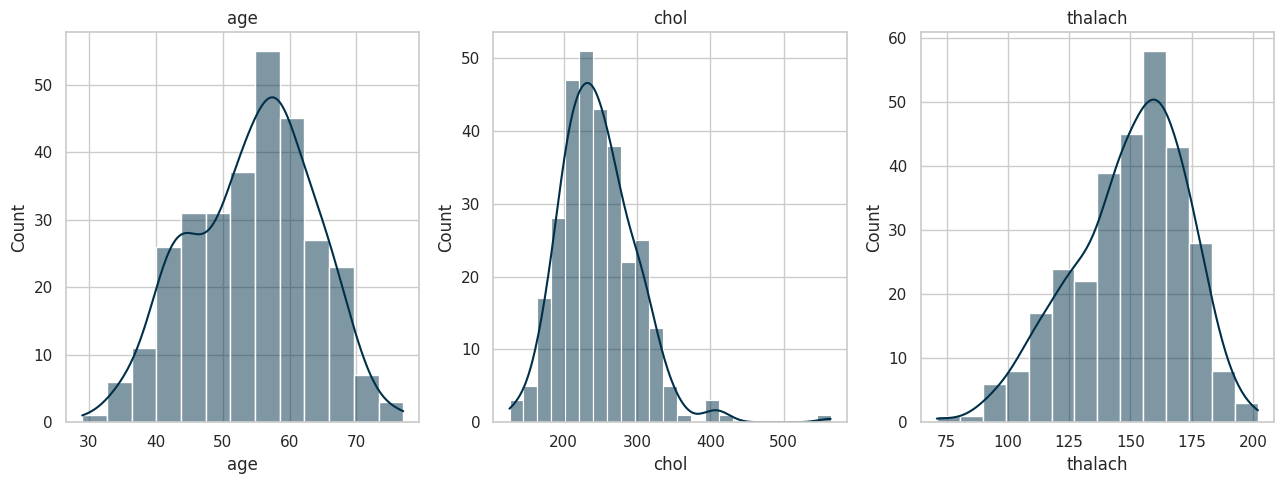

In [9]:
# TODO: histogram for the 'age', 'chol', 'thalach' columns
fig, ax = plt.subplots(1, 3, figsize=(13, 5))

for a, col in zip(ax, ["age", "chol", "thalach"]):
    sns.histplot(X[col], kde=True, ax=a, color="#003049")
    a.set_title(col)

plt.tight_layout()
plt.show()

## 6. Feature vs target
The maximum heart rate reached (thalach) tends to be lower in patients with disease. Let us check with a boxplot.

/tmp/ipykernel_3047/2050533740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="disease", y="thalach", palette=["#669bbc","#c1121f"])


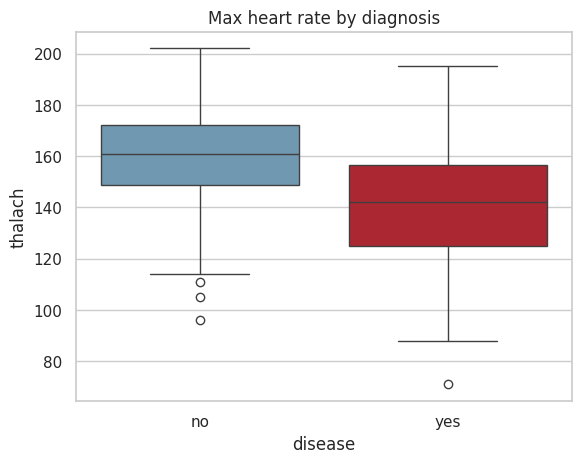

In [10]:
# TODO: boxplot of 'thalach' split by 'disease'
df = X.assign(disease=y)
sns.boxplot(data=df, x="disease", y="thalach", palette=["#669bbc","#c1121f"])
plt.xticks([0,1], ["no","yes"]); plt.title("Max heart rate by diagnosis"); plt.show()

## 7. Correlations
Heatmap of the correlations among the numeric features. Which pairs move together?

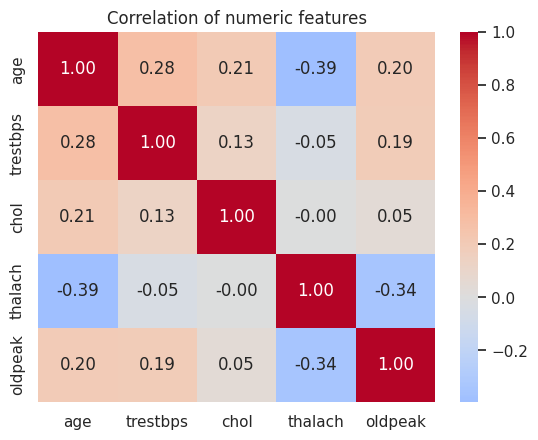

In [11]:
corr = X[numeric].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of numeric features")
plt.show()

## 8. A first, honest model
Split the data into **train** and **test**, fill the missing values, and see how much better a simple model
is than the "always predict the majority class" baseline.
> Important: fit the imputer on the **training data only** - the pipeline guarantees this (no leakage).

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# 20% test, random_state=42, stratified split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)),
])

pipe.fit(X_tr, y_tr)

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)

print("Baseline dummy:", round(accuracy_score(y_te, dummy.predict(X_te)), 3))
print("Logistic regression:", round(accuracy_score(y_te, pipe.predict(X_te)), 3))

Baseline dummy: 0.541
Logistic regression: 0.869


## Questions to think about
1. Why is accuracy alone not enough on this dataset?
2. What would we get wrong if we imputed the missing values on the **whole** dataset before the split?
3. Based on the `thalach`-`age` relationship, what would you expect from a regression task (Session 3)?

*Next session: classical models and classification - logistic regression, SVM, decision tree, and dimensionality reduction.*